In [1]:
import numpy as np
import numpy.linalg
import scipy as sp
import matplotlib.pyplot as plt
import numba as nb
from numba.experimental import jitclass

from matplotlib import cm

import os
import sys
script_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(script_dir, '..','Src'))  # adjust '..' depending where you are
sys.path.insert(0, project_root)

import  MadWa as mad

In [2]:
W1 = mad.wan.WanRes('wannier90.1')

In [6]:
TB1 = mad.nlb.TB()
TB1.fromWanRes(W1,W1)

In [10]:
NLB1 = mad.nlb.Boltzmann(TB1, 16,  MaxOrd = 1, Name='test1', der_N =3)

In [11]:
NLB1.initDerivs()
NLB1.SaveDerivs()

In [12]:
ex = np.array((1,0,0))

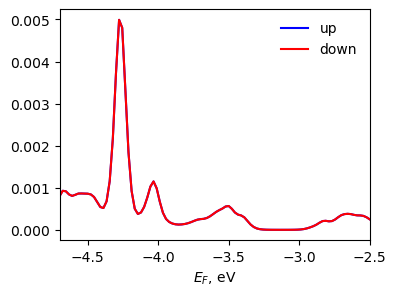

In [14]:
res1 = NLB1.EFcurrent(1, -4.7, -2.5, ex, ex, Show=True, TK=300, tau=10)

In [9]:
TB1.getHk(np.zeros(3))

(array([[-4.203278e+00+0.000e+00j,  9.148000e-03-1.730e-04j,
         -9.065000e-03-5.010e-04j, ..., -3.627780e-01+9.740e-04j,
          9.820000e-04+7.570e-04j,  4.663800e-02+1.426e-03j],
        [ 9.148000e-03+1.730e-04j, -5.234486e+00+0.000e+00j,
          3.892900e-02+1.500e-05j, ...,  1.240370e-01-9.400e-04j,
         -3.796000e-03+3.300e-05j, -8.159000e-02-1.150e-04j],
        [-9.065000e-03+5.010e-04j,  3.892900e-02-1.500e-05j,
         -5.143055e+00+0.000e+00j, ...,  7.939100e-02+4.300e-05j,
         -3.710000e-03-4.560e-04j,  1.311420e-01+8.790e-04j],
        ...,
        [-3.627780e-01-9.740e-04j,  1.240370e-01+9.400e-04j,
          7.939100e-02-4.300e-05j, ...,  2.544641e+00+0.000e+00j,
          1.295300e-02-2.637e-03j, -1.304270e-01-2.366e-03j],
        [ 9.820000e-04-7.570e-04j, -3.796000e-03-3.300e-05j,
         -3.710000e-03+4.560e-04j, ...,  1.295300e-02+2.637e-03j,
          2.874184e+00+0.000e+00j, -1.844590e-01-7.136e-03j],
        [ 4.663800e-02-1.426e-03j, -8.1590

In [11]:
i=4
W1.rvecs[i]

array([0, 0, 0])

In [14]:
W1.Hr[i].shape

(218, 218)

In [3]:
help(mad.nlb)

Help on package MadWa.NLBolt in MadWa:

NAME
    MadWa.NLBolt

PACKAGE CONTENTS
    Boltzmann1 (package)
    Io (package)
    Math (package)
    Models (package)
    Utils (package)

FILE
    c:\and\valencia\madwa\src\madwa\nlbolt\__init__.py




In [6]:
help(mad.nlb.Boltzmann)

Help on class Boltzmann in module MadWa.NLBolt.Boltzmann1.NLBoltzmann:

class Boltzmann(builtins.object)
 |  Boltzmann(TB, Nk, dim=2, MaxOrd=3, der_N=None, der_dk=None, der_dkGau=None, Name='Blt')
 |
 |  Methods defined here:
 |
 |  EFcurrent(self, Order, EF1, EF2, Evec, Jvec, Np=100, npz_file=None, txt_file=None, Show=False, fig_file=None, TK=300, tau=100)
 |      Calculates the dependence of the current density on the Fermi energy
 |      Order - order of the perturbation theory
 |      EF1, EF2 - minimum and maximum Fermi energy
 |      Evec - vector of the electric field
 |      Jvec - direction of the measured current density
 |      Np - number of "points": Fermi energies
 |      npz_file: (if provided) saves the results in this file in npz-format
 |      txt_file: (if provided) saves the results in this file in text format
 |      Show: if True: makes a plot of the results
 |      fig_file: (only for Show=True) if provided, saves the figure in the file
 |      TK:  temperature [